#### Import

In [69]:
from ipynb.fs.full.preprocessOne import train_ds, val_ds, test_ds, NUM_CLASSES
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import tensorflow as tf

#### Initialize Model (EfficientNetB0)

In [76]:
myNetB0 = EfficientNetB0(
    include_top=False, # Using my own labels (I think that is what this does)
    weights="imagenet",
    input_shape=(224,224,3) # Image Size
)

myNetB0.trainable = False # Stops previous traning weights from leaking into this new task

# I literally have no idea what is happening here ----------------------------------
x = layers.GlobalAveragePooling2D()(myNetB0.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation="softmax", name="flower_type")(x)
# ----------------------------------------------------------------------------------

myModelFixed = Model(inputs=myNetB0.input, outputs=output)

myModelFixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",  # checks how much the model got wrong (changed from catergorical to sparse)
    metrics=["accuracy"] # Judges who to decide what the model got right
)

#### Callbacks

In [78]:
callbacks = [
    # Stop early if val_loss stops improving
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5, # If no improvement after 5 epochs, stops
        restore_best_weights=True
    ),
    # Reduce learning rate when val_loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    ),
    # Save the best model to disk
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

#### Training

In [79]:
history = myModelFixed.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 71s 647ms/step - accuracy: 0.2218 - loss: 2.0660 - val_accuracy: 0.1698 - val_loss: 1.6387 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.2191 - loss: 1.9627 - val_accuracy: 0.1790 - val_loss: 1.6081 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.2281 - loss: 1.8660 - val_accuracy: 0.2191 - val_loss: 1.6060 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.2234 - loss: 1.7455 - val_accuracy: 0.3410 - val_loss: 1.6059 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.2340 - loss: 1.6770 - val_accuracy: 0.2284 - val_loss: 1.6081 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.2479 - loss: 1.6555 - val_accuracy: 0.2284 - val_loss: 1.6069 - learning_rate: 0.0010
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 88s 922ms/step - accuracy: 0.2456 - loss: 1.6260 - val

#### Graph Epochs (AI)

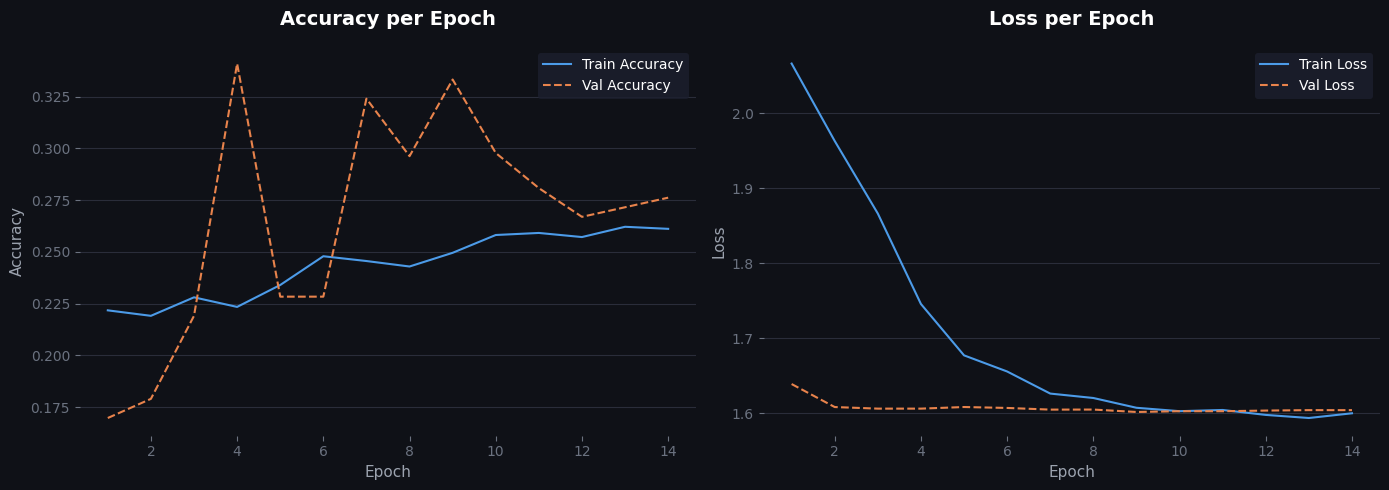

In [80]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0F1117")

epochs = range(1, len(history.history["accuracy"]) + 1)

for ax in (ax1, ax2):
    ax.set_facecolor("#0F1117")
    ax.yaxis.grid(True, color="#2A2D3A", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="#6B7280")

# --- Accuracy ---
ax1.plot(epochs, history.history["accuracy"],     color="#4C9BE8", label="Train Accuracy")
ax1.plot(epochs, history.history["val_accuracy"], color="#E8834C", label="Val Accuracy", linestyle="--")
ax1.set_title("Accuracy per Epoch",  color="white", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Epoch",              color="#9CA3AF", fontsize=11)
ax1.set_ylabel("Accuracy",           color="#9CA3AF", fontsize=11)
ax1.legend(facecolor="#1C1F2E", edgecolor="none", labelcolor="white")

# --- Loss ---
ax2.plot(epochs, history.history["loss"],     color="#4C9BE8", label="Train Loss")
ax2.plot(epochs, history.history["val_loss"], color="#E8834C", label="Val Loss", linestyle="--")
ax2.set_title("Loss per Epoch",  color="white", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Epoch",          color="#9CA3AF", fontsize=11)
ax2.set_ylabel("Loss",           color="#9CA3AF", fontsize=11)
ax2.legend(facecolor="#1C1F2E", edgecolor="none", labelcolor="white")

plt.tight_layout()
plt.show()

#### Fine Tuning

In [82]:
# Unfreeze the base model
myModelFixed.layers[0].trainable = True

# Recompile with a much lower learning rate
myModelFixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = myModelFixed.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 361ms/step - accuracy: 0.2668 - loss: 1.6013 - val_accuracy: 0.3395 - val_loss: 1.6010 - learning_rate: 1.0000e-05
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 348ms/step - accuracy: 0.2622 - loss: 1.5953 - val_accuracy: 0.3457 - val_loss: 1.6009 - learning_rate: 1.0000e-05
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 36s 377ms/step - accuracy: 0.2572 - loss: 1.6017 - val_accuracy: 0.3349 - val_loss: 1.6010 - learning_rate: 1.0000e-05
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 409ms/step - accuracy: 0.2681 - loss: 1.5905 - val_accuracy: 0.3287 - val_loss: 1.6003 - learning_rate: 1.0000e-05
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 79s 835ms/step - accuracy: 0.2632 - loss: 1.5943 - val_accuracy: 0.3519 - val_loss: 1.6015 - learning_rate: 1.0000e-05
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 72s 757ms/step - accuracy: 0.2595 - loss: 1.5989 - val_accuracy: 0.3410 - val_loss: 1.6005 - learning_rate: 1.0000e-05
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 74s 781ms/step - acc

#### Graph Epochs of Tuned Model

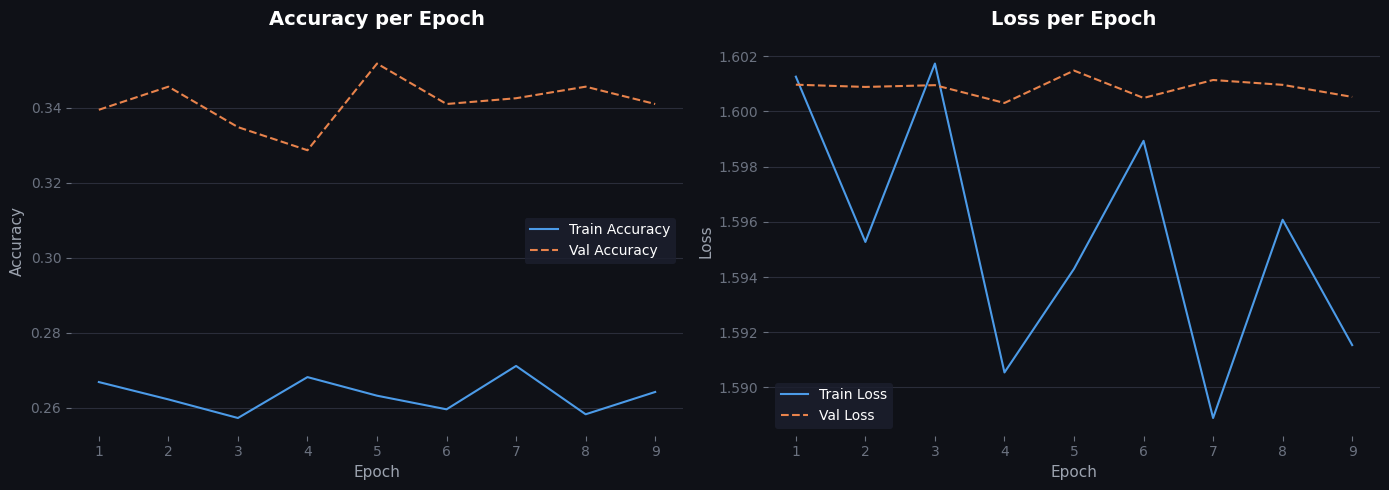

In [83]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0F1117")

epochs = range(1, len(history_finetune.history["accuracy"]) + 1)

for ax in (ax1, ax2):
    ax.set_facecolor("#0F1117")
    ax.yaxis.grid(True, color="#2A2D3A", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="#6B7280")

# --- Accuracy ---
ax1.plot(epochs, history_finetune.history["accuracy"],     color="#4C9BE8", label="Train Accuracy")
ax1.plot(epochs, history_finetune.history["val_accuracy"], color="#E8834C", label="Val Accuracy", linestyle="--")
ax1.set_title("Accuracy per Epoch",  color="white", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Epoch",              color="#9CA3AF", fontsize=11)
ax1.set_ylabel("Accuracy",           color="#9CA3AF", fontsize=11)
ax1.legend(facecolor="#1C1F2E", edgecolor="none", labelcolor="white")

# --- Loss ---
ax2.plot(epochs, history_finetune.history["loss"],     color="#4C9BE8", label="Train Loss")
ax2.plot(epochs, history_finetune.history["val_loss"], color="#E8834C", label="Val Loss", linestyle="--")
ax2.set_title("Loss per Epoch",  color="white", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Epoch",          color="#9CA3AF", fontsize=11)
ax2.set_ylabel("Loss",           color="#9CA3AF", fontsize=11)
ax2.legend(facecolor="#1C1F2E", edgecolor="none", labelcolor="white")

plt.tight_layout()
plt.show()

#### Evaluate on Test Set

In [56]:
test_loss, test_accuracy = myModelFixed.evaluate(test_ds)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step - accuracy: 0.2639 - loss: 1.6012
Test Loss:     1.6012
Test Accuracy: 0.2639
